###scikit-learn

Strona biblioteki: https://scikit-learn.org/

Dokumentacja/User Guide: https://scikit-learn.org/stable/user_guide.html

Podstawowa biblioteka do uczenia maszynowego w języku Python.
Aby zainstalować bibliotekę scikit-learn użyj polecenia poniżej.

Instrukcja instalacji biblioteki scikit-learn w środowisku lokalnym

In [1]:
!pip install scikit-learn

Instrukcja aktualizacji biblioteki scikit-learn w środowisku lokalnym

In [2]:
!pip install --upgrade scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ----------------- ---------------------- 3.7/8.2 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 19.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 17.3 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2


**data** - wszystkie nasze dane na podstawie, których będzimey chcieli przewidywać zmienną docelową czyli target.

data składa się atrybutow (atrybutów kategoprycznych inaczej nazywane kategorialnymi oraz atrybutów numerycznych)


**target** - zmienna docelowa czyli to co chcemy przewidywać.



###W znacznej większości modeli wymaga się aby dane wprowadzone do modelu były danymi numerycznymi.

Jeżeli zatem zdarzy się, że w naszym zbiorze danych mamy dane kategoryczne musimy je przemapować na dane numeryczne.

###Przygotowanie danych do modelu:

* Zamiana danych kategorycznych na dane liczbowe. (Zakodowanie zmiennych kategorycznych)

* Standaryzania danych liczbowych - najczęsciej stosowany przykład standaryzacji odjąć średnia, podzielić przez odchylenie standardowe.

(stosujemy zwłaszcza w przypadku gdy pomiędzy danymi w modelu występuje znaczna dysproporcja)

### Preprocessing danych:
1. [Import bibliotek](#0)
2. [Wygenerowanie danych](#1)
3. [Utworzenie kopii danych](#2)
4. [Zmiana typu danych i wstępna eksploracja](#3)
5. [LabelEncoder](#4)
6. [OneHotEncoder](#5)
7. [Pandas get_dummies()](#6)
8. [Braki danych](#7)
9. [Ekstrakcja cech](#8)
10. [Zbior treningowy, testowy, walidacyjny](#9)

### <a name='0'></a> Import bibliotek

In [ ]:
import numpy as np
import pandas as pd
import sklearn

sklearn.__version__

'1.6.1'

### <a name='1'></a> Wygenerowanie danych

In [ ]:
# import pandas as pd

# data = pd.read_csv('https://storage.googleapis.com/esmartdata-courses-files/ds-bootcamp/online')

In [ ]:
data = {
    'size': ['XL', 'L', 'M', 'L', 'M'],
    'color': ['red', 'green', 'blue', 'green', 'red'],
    'gender': ['female', 'male', 'male', 'female', 'female'],
    'price': [199.0, 89.0, 99.0, 129.0, 79.0],
    'weight': [500, 450, 300, 380, 410],
    'bought': ['yes', 'no', 'yes', 'no', 'yes']
}

df_raw = pd.DataFrame(data=data)
df_raw

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500,yes
1,L,green,male,89.0,450,no
2,M,blue,male,99.0,300,yes
3,L,green,female,129.0,380,no
4,M,red,female,79.0,410,yes


### <a name='2'></a> Utworzenie kopii danych

Dodatkowo wyświetlamy również podstawowe informacje na temat naszego obiektu.

Domyślnie biblioteka pandas stara się odczytać jakie typy danych występują w naszym obiekcie Data Frame.

W naszym zbiorze danych mamy typ: float64  - price, int64 - weight oraz poozstałe to typ object.

Dane typu object możemy zostawić lub możemy też i jest to wskazane, przetworzenie typu object na typ kategoryczny.

In [ ]:
df = df_raw.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   size    5 non-null      object 
 1   color   5 non-null      object 
 2   gender  5 non-null      object 
 3   price   5 non-null      float64
 4   weight  5 non-null      int64  
 5   bought  5 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 372.0+ bytes


### <a name='3'></a> Zmiana typu danych i wstepna eksploracja

In [ ]:
for col in ['size', 'color', 'gender', 'bought']:
  df[col] = df[col].astype('category')

df['weight'] = df['weight'].astype('float')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   size    5 non-null      category
 1   color   5 non-null      category
 2   gender  5 non-null      category
 3   price   5 non-null      float64 
 4   weight  5 non-null      float64 
 5   bought  5 non-null      category
dtypes: category(4), float64(2)
memory usage: 744.0 bytes


Podstawowe statystyki dotyczące obiektu Data Frame.

Należy wskazać, iż domyślnie metoda describe() wyswietla jedynie statystyki dla kolumn numerycznych.

In [ ]:
df.describe()

,price,weight
count,5.000000,5.000000
mean,119.000000,408.000000
std,48.476799,75.299402
min,79.000000,300.000000
25%,89.000000,380.000000
50%,99.000000,410.000000
75%,129.000000,450.000000
max,199.000000,500.000000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,5.0,119.0,48.476799,79.0,89.0,99.0,129.0,199.0
weight,5.0,408.0,75.299402,300.0,380.0,410.0,450.0,500.0


Wyświetlamy statystyki na temat zmiennych, które są zmiennymi kategorycznymi.

In [ ]:
df.describe(include=['category']).T

,count,unique,top,freq
size,5,3,L,2
color,5,3,green,2
gender,5,2,female,3
bought,5,2,yes,3


###Rozpoczynamy przygotowanie danych do uczenia maszynowego

### <a name='4'></a> LabelEncoder (kodowanie)

Warto zwrócić uwagę, iż klasa LabelEncoder wykorzytywana jest głownie do przeksztalcania naszych zmiennych docelowych (target).

Raczej nie stosujemy tej klasy ze zmiennymi opisujacymi.

Naszą pracę rozpoczniemy od przygotowania naszej zmiennej wynikowej.

Zatem chcemy przemapować zmienną o nazwie "bought":

wartość yes => 1
wartość no => 0

Warto zapamiętać, że klasa Label Encoder została stworzona głownie do przekształcania zmiennych docelowych, w naszym przypadku zmiennej bought.

Nie stosujemy raczej tej klasy do przekształcania innych zmiennych opisujących zmienną docelową. Do tego celu mamy przeznacozne inne narzędzie.

In [ ]:
from sklearn.preprocessing import LabelEncoder

#Tworzymy instancję klasy i przypisujemy ją do zmiennej le
le = LabelEncoder()
#Korzystamy z metody fit(), która dopasuje Encoder do naszej zmiennej. W tym przypadku df['bought']
le.fit(df['bought'])
#Na koniec użyjemy metody transform() aby przetransformowała (przemapowała) nasze dane do modelu.
le.transform(df['bought'])

array([1, 0, 1, 0, 1])

In [ ]:
le.fit_transform(df['bought'])

array([1, 0, 1, 0, 1])

W przypadku gdy mamy więcej klas, warto wiedzieć jak mapowanie przebiega.

Mamy więc atrybut classes, który pozwali nam wyświetlić mapowanie.

In [ ]:
le.classes_

array(['no', 'yes'], dtype=object)

Jeżeli chcemy przekazać obiekt Data Frame do modelu, to musimy przypisać na stałe zmianę do obiektu Data Frame.

In [ ]:
df['bought'] = le.fit_transform(df['bought'])

In [ ]:
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,1
1,L,green,male,89.0,450.0,0
2,M,blue,male,99.0,300.0,1
3,L,green,female,129.0,380.0,0
4,M,red,female,79.0,410.0,1


Jeżeli wydażyłoby się tak, że chcielibyśmy wrócić do pierwotnej postaci i wyświetlić zawartość df['bought'] - mamy taką możliwość

In [ ]:
df['bought'] = le.inverse_transform(df['bought'])
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,male,99.0,300.0,yes
3,L,green,female,129.0,380.0,no
4,M,red,female,79.0,410.0,yes


### <a name='5'></a> OneHotEncoder

Kodowanie zmiennych opisujących (objaśniających)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
#Tworzymy instancję klasy i przypisujemy ją do zmiennej encoder
#Zmienimy parametr sparse_output na False. Klasa ta domyślnie zwraca macierz rzadką - nie jesteśmy w stanie podejrzeć jak ona wygląda.
#Macierz rzadka - jeżeli macierz w znacznej większości składa się z zer, nie ma sensu przochowywać w pamięci całej macierzy.
#Wystarczy przechowywać w pamięci pozycje, na których znajduje się wartość inna niż zero.
#Poza tym doskonale wiemy, że w pozostałych miejscach będą zera.
#Spora oszczędność pamięci podczas takiego kodowania.
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(df[['size']])

OneHotEncoder(sparse_output=False)

In [ ]:
encoder.transform(df[['size']])

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [ ]:
encoder.categories_

[array(['L', 'M', 'XL'], dtype=object)]

Natomiast warto wskazać, że przy takim kodowaniu możemy popełnić błąd kodowania zero-jedynkowego.

Możemy mieć liniową zależność pomiędzy zmiennymi.


Aby wyeliminować ten czynnik w kolejnym kroku, dodatkowo przekażemy parametr drop='first' - usuwa pierwszą z kolumn.



Zapamiętaj, iż w przypadku posiadania n-różnych wartości zmiennej kategorycznej, po kodowaniu zero-jedynkowym mamy n-1 kolum, które zostaną zakodowane.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoder.fit(df[['size']])
encoder.transform(df[['size']])

array([[0., 1.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [1., 0.]])

In [ ]:
encoder.categories_

[array(['L', 'M', 'XL'], dtype=object)]

Wygląd obiektu Data Frame

In [ ]:
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,male,99.0,300.0,yes
3,L,green,female,129.0,380.0,no
4,M,red,female,79.0,410.0,yes


### <a name='6'></a> Pandas get_dummies()

Funkcja get_dummies umożliwia znacznie bardziej elastyczne kodowanie aniżeli klasa OneHotEncoder z biblioteki sklearn.

Obiekt Data Frame przekazany zostanie do funkcji get_dummies biblioteki pandas

Funkcja det_dummies zakodawała wszytskie zmienne kategoryczne.



In [ ]:
pd.get_dummies(data=df, dtype=int)

,price,weight,size_L,size_M,size_XL,color_blue,color_green,color_red,gender_female,gender_male,bought_no,bought_yes
0,199.0,500.0,0,0,1,0,0,1,1,0,0,1
1,89.0,450.0,1,0,0,0,1,0,0,1,1,0
2,99.0,300.0,0,1,0,1,0,0,0,1,0,1
3,129.0,380.0,1,0,0,0,1,0,1,0,1,0
4,79.0,410.0,0,1,0,0,0,1,1,0,0,1


Poprzez wykorzystanie dodatkowego parametru drop_first="True" możemy usunąć kolumnę wpływającą na powstawanie liniowej zależności pomiędzy zmiennymi w modelu.

In [ ]:
pd.get_dummies(data=df, drop_first=True, dtype=int)

,price,weight,size_M,size_XL,color_green,color_red,gender_male,bought_yes
0,199.0,500.0,0,1,0,1,0,1
1,89.0,450.0,0,0,1,0,1,0
2,99.0,300.0,1,0,0,0,1,1
3,129.0,380.0,0,0,1,0,0,0
4,79.0,410.0,1,0,0,1,0,1


In [ ]:
pd.get_dummies(data=df, drop_first=True, prefix='new', dtype=int)

,price,weight,new_M,new_XL,new_green,new_red,new_male,new_yes
0,199.0,500.0,0,1,0,1,0,1
1,89.0,450.0,0,0,1,0,1,0
2,99.0,300.0,1,0,0,0,1,1
3,129.0,380.0,0,0,1,0,0,0
4,79.0,410.0,1,0,0,1,0,1


In [ ]:
pd.get_dummies(data=df, drop_first=True, prefix_sep='-', dtype=int)

,price,weight,size-M,size-XL,color-green,color-red,gender-male,bought-yes
0,199.0,500.0,0,1,0,1,0,1
1,89.0,450.0,0,0,1,0,1,0
2,99.0,300.0,1,0,0,0,1,1
3,129.0,380.0,0,0,1,0,0,0
4,79.0,410.0,1,0,0,1,0,1


Przekazując parametr columns mamy możliwość wykonania kodowania jedynie dla wybranych kolumn.

In [ ]:
pd.get_dummies(data=df, drop_first=True, columns=['size'], dtype=int)

,color,gender,price,weight,bought,size_M,size_XL
0,red,female,199.0,500.0,yes,0,1
1,green,male,89.0,450.0,no,0,0
2,blue,male,99.0,300.0,yes,1,0
3,green,female,129.0,380.0,no,0,0
4,red,female,79.0,410.0,yes,1,0


### <a name='6'></a> Standaryzacja danych - StandarScaler

Standaryzacja - ogólnie rzecz ujmując jest to proces w wyniku, ktorego doprowadzamy do takiej postaci, w której skala wartości nie ma znaczenia.

Natomiast znaczenie ma ich rozrzut czyli wariancja.

Przykładowo jeżeli w naszym modelu mamy wartości bardzo duże i mniejsze (w naszym przypadku wartości price i weight), ta większa wartość może bardzo wpłynąć na model.

W takim przypadku może się zdarzyć, że bardzo istotne informacje dla modelu przechowywane w mniejszej wartości zostaną po prostu utracone.

Dlatego w takim przypadku nalepiej dane wystandaryzować.

**Odchylenie standardowe** jest estymatorem obciążonym wariancji.

std() -pandas nieobciążony

std() - numpy obciążony

Przy liczeniu wariancji czy odchylenia standardowego mogą wychodzić nieco inne wyniki - zaimplementowana postać estymatora jest inna.



In [ ]:
print(f"{df['price']}\n")

0    199.0
1     89.0
2     99.0
3    129.0
4     79.0
Name: price, dtype: float64



In [ ]:
print(f"Średnia: {df['price'].mean()}")

Średnia: 119.0


In [ ]:
print(f"Odchylenie standardowe: {df['price'].std():.4f}")

Odchylenie standardowe: 48.4768


In [ ]:
print(f"{df['price']}\n")
print(f"Średnia: {df['price'].mean()}")
print(f"Odchylenie standardowe: {df['price'].std():.4f}")

0    199.0
1     89.0
2     99.0
3    129.0
4     79.0
Name: price, dtype: float64

Średnia: 119.0
Odchylenie standardowe: 48.4768


In [ ]:
(df['price'] - df['price'].mean()) /df['price'].std()

,price
0,1.650274
1,-0.618853
2,-0.412568
3,0.206284
4,-0.825137


Możemy napisać swoją własną funkcję służącą do wystandaryzowania zmiennych

In [ ]:
def standardize(x):
  return (x - x.mean()) / x.std()

standardize(df['price'])

,price
0,1.650274
1,-0.618853
2,-0.412568
3,0.206284
4,-0.825137


Zwróć uwagę, iż wartości uzyskane w wyniku standaryzacji za pomocą biblioteki sklearn są inne niż te uzyskane w wyniu pracy z biblioteką pandas.

Jest to zwioązane z estymatorem obciążonym i nieobciążony wariancji, o którym była mowa nieco wcześniej.

In [ ]:
from sklearn.preprocessing import scale

scale(df['price'])

array([ 1.84506242, -0.69189841, -0.4612656 ,  0.2306328 , -0.92253121])

Gotowa klasa StandarScaler, która jest nieco lepsza od funkcji *scale()*, ponieważ ta klasa pozwala nam zachowac na przyszłość wartosci statystyk.

In [ ]:
from sklearn.preprocessing import StandardScaler

#Tworzymy instancje klasy i przypisujemy ją do zmiennej scaler
scaler = StandardScaler()
#Uzywamy metody fit, która obliczy statystyki, które potrzebujemy do standaryzacji
scaler.fit(df[['price']])
#Metoda transform pozwala te dane przekształcić
scaler.transform(df[['price']])

array([[ 1.84506242],
       [-0.69189841],
       [-0.4612656 ],
       [ 0.2306328 ],
       [-0.92253121]])

In [ ]:
scaler = StandardScaler()
df[['price', 'weight']] = scaler.fit_transform(df[['price', 'weight']])
df

,size,color,gender,price,weight,bought
0,XL,red,female,1.845062,1.366002,yes
1,L,green,male,-0.691898,0.623610,no
2,M,blue,male,-0.461266,-1.603567,yes
3,L,green,female,0.230633,-0.415740,no
4,M,red,female,-0.922531,0.029696,yes


### Powtórka

In [ ]:
df = df_raw.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   size    5 non-null      object 
 1   color   5 non-null      object 
 2   gender  5 non-null      object 
 3   price   5 non-null      float64
 4   weight  5 non-null      int64  
 5   bought  5 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 372.0+ bytes


In [ ]:
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500,yes
1,L,green,male,89.0,450,no
2,M,blue,male,99.0,300,yes
3,L,green,female,129.0,380,no
4,M,red,female,79.0,410,yes


In [ ]:
le = LabelEncoder()

df['bought'] = le.fit_transform(df['bought'])

scaler = StandardScaler()
df[['price', 'weight']] = scaler.fit_transform(df[['price', 'weight']])

df = pd.get_dummies(data=df, drop_first=True, columns=['size', 'color', 'gender'], dtype=int)
df

,price,weight,bought,size_M,size_XL,color_green,color_red,gender_male
0,1.845062,1.366002,1,0,1,0,1,0
1,-0.691898,0.623610,0,0,0,1,0,1
2,-0.461266,-1.603567,1,1,0,0,0,1
3,0.230633,-0.415740,0,0,0,1,0,0
4,-0.922531,0.029696,1,1,0,0,1,0


### <a name='7'></a> Braki danych

Praca z brakami danych:

*   Usunięcie rekordów z brakami (rozwiązanie dla dużych i bardzo dużych zbiorów danych).
*   Wypełnienie braków stałą wartością (średnia, mediana)
Ważne! W celu uzupełnienia braków danych (np. średnią czy też medianą) obliczeń dokonujemy na zbiorze treningowym.
Podejście takie zapobiega "wyciekowi informacji" ze zbioru testowego.
*   Wytrenowanie modelu w celu uzupełniania braków
*   Zastosowanie interpolacji (szeregi czasowe)
*   Dodanie nowej kategorii "brak" (zmienne kategoryczne)








In [ ]:
import numpy as np
import pandas as pd
import sklearn

sklearn.__version__

'1.6.1'

In [ ]:
data = {
    'size': ['XL', 'L', 'M', np.nan, 'M', 'M'],
    'color': ['red', 'green', 'blue', 'green', 'red', 'green'],
    'gender': ['female', 'male', np.nan, 'female', 'female', 'male'],
    'price': [199.0, 89.0, np.nan, 129.0, 79.0, 89.0],
    'weight': [500, 450, 300, np.nan, 410, np.nan],
    'bought': ['yes', 'no', 'yes', 'no', 'yes', 'no']
}

df_raw = pd.DataFrame(data=data)
df_raw

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


In [ ]:
df = df_raw.copy()
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   size    5 non-null      object 
 1   color   6 non-null      object 
 2   gender  5 non-null      object 
 3   price   5 non-null      float64
 4   weight  4 non-null      float64
 5   bought  6 non-null      object 
dtypes: float64(2), object(4)
memory usage: 420.0+ bytes


###Sprawdzamy czy braki danych w naszym zbiorze danych rzeczywiście istnieją.

Metoda zwraca maskę logiczną.

In [ ]:
df.isnull()

,size,color,gender,price,weight,bought
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,True,True,False,False
3,True,False,False,False,True,False
4,False,False,False,False,False,False
5,False,False,False,False,True,False


###Wyznaczamy sumaryczną wartość braków danych dla każdej kolumny (dla każdej zmiennej)

In [ ]:
df.isnull().sum()

,0
size,1
color,0
gender,1
price,1
weight,2
bought,0


###Łączna liczba braków danych w naszym obiekcie DataFrame

In [ ]:
df.isnull().sum().sum()

5

###Procent braków danych dla każdej zmiennej

In [ ]:
df.isnull().sum() / len(df)

size      0.166667
color     0.000000
gender    0.166667
price     0.166667
weight    0.333333
bought    0.000000
dtype: float64

### Uzupełnianie braków - Simplelmputer

In [ ]:
from sklearn.impute import SimpleImputer

# strategy: 'mean', 'median', 'most frequent', 'constant'

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(df[['weight']])

SimpleImputer()

###Zwróci wartość jaka została obliczona - wartość uzupełniona w miejscu braków.

In [ ]:
imputer.statistics_

array([415.])

In [ ]:
imputer.transform(df[['weight']])

array([[500.],
       [450.],
       [300.],
       [415.],
       [410.],
       [415.]])

In [ ]:
df['weight'] = imputer.transform(df[['weight']])
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,415.0,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,415.0,no


In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=99.0)
imputer.fit_transform(df[['price']])

array([[199.],
       [ 89.],
       [ 99.],
       [129.],
       [ 79.],
       [ 89.]])

In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='L')
imputer.fit_transform(df[['size']])

array([['XL'],
       ['L'],
       ['M'],
       ['L'],
       ['M'],
       ['M']], dtype=object)

In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imputer.fit_transform(df[['size']])

array([['XL'],
       ['L'],
       ['M'],
       ['M'],
       ['M'],
       ['M']], dtype=object)

In [ ]:
df = df_raw.copy()
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


In [ ]:
df.isnull().sum()

,0
size,1
color,0
gender,1
price,1
weight,2
bought,0


In [ ]:
pd.isnull(df['weight'])

,weight
0,False
1,False
2,False
3,True
4,False
5,True


In [ ]:
df[pd.isnull(df['weight'])]

,size,color,gender,price,weight,bought
3,NaN,green,female,129.0,NaN,no
5,M,green,male,89.0,NaN,no


### Jeżeli chcemy zwrócić przeciwnie -> używamy znaku ~

In [ ]:
df[~pd.isnull(df['weight'])]

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
4,M,red,female,79.0,410.0,yes


In [ ]:
pd.notnull(df['weight'])

,weight
0,True
1,True
2,True
3,False
4,True
5,False


In [ ]:
df[pd.notnull(df['weight'])]

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
4,M,red,female,79.0,410.0,yes


In [ ]:
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


In [ ]:
df.fillna(value='brak')

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,brak,brak,300.0,yes
3,brak,green,female,129.0,brak,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,brak,no


In [ ]:
df.fillna(value=0.0)

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,0.0,0.0,300.0,yes
3,0.0,green,female,129.0,0.0,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,0.0,no


In [ ]:
df['weight'].fillna(value=0.0)

,weight
0,500.0
1,450.0
2,300.0
3,0.0
4,410.0
5,0.0


In [ ]:
df['size'].fillna(value='L', inplace=True)
df

<ipython-input-64-2d54d505b881>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['size'].fillna(value='L', inplace=True)


,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,L,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


###Usuwamy wiersze z brakami danych

In [ ]:
df.dropna()

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
4,M,red,female,79.0,410.0,yes


### Braki danych w szeregach czasowych

In [ ]:
data = {'price': [108, 109, 110, 110, 109, np.nan, np.nan, 112, 111, 111]}
date_range = pd.date_range(start='01-01-2023 00:00', end='31-12-2023 23:00', periods=10)

df= pd.DataFrame(data=data, index=date_range)
df

,price
2023-01-01 00:00:00,108.0
2023-02-10 13:13:20,109.0
2023-03-23 02:26:40,110.0
2023-05-02 15:40:00,110.0
2023-06-12 04:53:20,109.0
2023-07-22 18:06:40,NaN
2023-09-01 07:20:00,NaN
2023-10-11 20:33:20,112.0
2023-11-21 09:46:40,111.0
2023-12-31 23:00:00,111.0


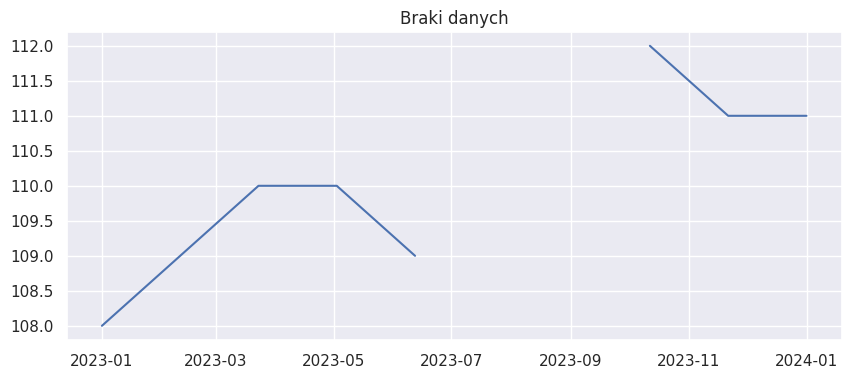

In [ ]:
from pandas.plotting import register_matplotlib_converters
import matplotlib.pyplot as plt
import seaborn as sns
register_matplotlib_converters()
sns.set()

plt.figure(figsize=(10, 4))
plt.title('Braki danych')
_ = plt.plot(df.price)

In [ ]:
import plotly.express as px

df_plotly = df.reset_index()
px.line(df_plotly, 'index', 'price', width=600, height=400,
        title='Szeregi czasowe - braki danych')

### Usunięcie braków danych

In [ ]:
df_plotly = df_plotly.dropna()

px.line(df_plotly, 'index', 'price', width=600, height=400, title='Szeregi czasowe - braki danych')

### Wypełnienie braków stałą wartością 0

In [ ]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(0)
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - wstawianie 0')

### Wypełnianie braków średnią

In [ ]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(df_plotly['price'].mean())
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - wstawianie średniej')

### Zastosowanie interpolacji

In [ ]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].interpolate()
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - interpolacja')

wypełnianiu brakujących wartości przy użyciu ostatniej dostępnej (niepustej) wartości z wcześniejszego wiersza

### Wypełnienie braków metodą forward fill

In [ ]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(method='ffill')
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - forward fill')

<ipython-input-73-8cb01e14c543>:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



### Wypełnienie braków danych metodą backward fill

In [ ]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(method='bfill')
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - backward fill')

<ipython-input-74-7e3835682aef>:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



### <a name='8'></a> Ekstrakcja cech

**Ekstrrakcja cech** czyli wydobywaniue dodatkowych cech z naszych danych.

Przyklady: zmiana procentowa ceny w czasie, wskaźniki analizy technicznej,

podział daty na dane typu: dzień, miesiąc, rok.

Przedstawianie danych w 2-3 kategoriach - wiążemy daną (bindujemy naszą daną ze zmienną).

In [ ]:
!pip install scikit-learn

In [ ]:
!pip install --upgrade scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import sklearn

sklearn.__version__

'1.6.1'

Możmey wyszukać inną spółkę, korzystając z tickerów.

In [ ]:
def fetch_financial_data(company='AMZN'):
  """
  This function fetches stock market quotattions.

  """

  import pandas_datareader.data as web
  return web.DataReader(name=company, data_source='stooq')



df_raw = fetch_financial_data()
df_raw.head()

,Open,High,Low,Close,Volume
Date,,,,,
2025-01-21,228.90,231.78,226.94,230.71,39951456
2025-01-17,225.84,226.51,223.08,225.94,42370123
2025-01-16,224.42,224.65,220.31,220.66,24757276
2025-01-15,222.83,223.57,220.75,223.35,31291257
2025-01-14,220.44,221.82,216.20,217.76,24711650


In [ ]:
df = df_raw.copy()
df = df[:5]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5 entries, 2025-01-21 to 2025-01-14
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5 non-null      float64
 1   High    5 non-null      float64
 2   Low     5 non-null      float64
 3   Close   5 non-null      float64
 4   Volume  5 non-null      int64  
dtypes: float64(4), int64(1)
memory usage: 240.0 bytes


In [ ]:
df['Volume'] = df['Volume'].astype('float')

In [ ]:
df

,Open,High,Low,Close,Volume
Date,,,,,
2025-01-21,228.90,231.78,226.94,230.71,39951456.0
2025-01-17,225.84,226.51,223.08,225.94,42370123.0
2025-01-16,224.42,224.65,220.31,220.66,24757276.0
2025-01-15,222.83,223.57,220.75,223.35,31291257.0
2025-01-14,220.44,221.82,216.20,217.76,24711650.0


###Generowanie nowych zmiennych

In [ ]:
df.index

DatetimeIndex(['2025-01-21', '2025-01-17', '2025-01-16', '2025-01-15',
               '2025-01-14'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [ ]:
df.index.day
df.index.month
df.index.year

Index([2025, 2025, 2025, 2025, 2025], dtype='int32', name='Date')

In [ ]:
df['day'] = df.index.day
df['month'] = df.index.month
df['year'] = df.index.year

df

,Open,High,Low,Close,Volume,day,month,year
Date,,,,,,,,
2025-01-21,228.90,231.78,226.94,230.71,39951456.0,21,1,2025
2025-01-17,225.84,226.51,223.08,225.94,42370123.0,17,1,2025
2025-01-16,224.42,224.65,220.31,220.66,24757276.0,16,1,2025
2025-01-15,222.83,223.57,220.75,223.35,31291257.0,15,1,2025
2025-01-14,220.44,221.82,216.20,217.76,24711650.0,14,1,2025


###Dyskretyzacja zmiennej ciaglej

Zwienną ciągłą chcielibyśmy przedstawić jako zmienną kategoryczną.

In [ ]:
df = pd.DataFrame(data={'height': [175.0, 178.5, 185.0, 191.0, 184.5, 183.0, 168]})
df

,height
0,175.0
1,178.5
2,185.0
3,191.0
4,184.5
5,183.0
6,168.0


In [ ]:
df['height_cut'] = pd.cut(x=df.height, bins=3)
df

,height,height_cut
0,175.0,"(167.977, 175.667]"
1,178.5,"(175.667, 183.333]"
2,185.0,"(183.333, 191.0]"
3,191.0,"(183.333, 191.0]"
4,184.5,"(183.333, 191.0]"
5,183.0,"(175.667, 183.333]"
6,168.0,"(167.977, 175.667]"


In [ ]:
df['height_cut'] = pd.cut(x=df.height, bins=(160, 175, 180, 195))
df

,height,height_cut
0,175.0,"(160, 175]"
1,178.5,"(175, 180]"
2,185.0,"(180, 195]"
3,191.0,"(180, 195]"
4,184.5,"(180, 195]"
5,183.0,"(180, 195]"
6,168.0,"(160, 175]"


In [ ]:
df['height_cat'] = pd.cut(x = df.height, bins=(160, 175, 180, 195), labels=['small', 'medium', 'height'])
df

,height,height_cut,height_cat
0,175.0,"(160, 175]",small
1,178.5,"(175, 180]",medium
2,185.0,"(180, 195]",height
3,191.0,"(180, 195]",height
4,184.5,"(180, 195]",height
5,183.0,"(180, 195]",height
6,168.0,"(160, 175]",small


In [ ]:
pd.get_dummies(df, drop_first=True, prefix='height')

,height,"height_(175, 180]","height_(180, 195]",height_medium,height_height
0,175.0,False,False,False,False
1,178.5,True,False,True,False
2,185.0,False,True,False,True
3,191.0,False,True,False,True
4,184.5,False,True,False,True
5,183.0,False,True,False,True
6,168.0,False,False,False,False


###Ekstrakcja cech

In [ ]:
df = pd.DataFrame(data={'lang': [['PL', 'ENG'], ['GER', 'ENG', 'PL', 'FRA'], ['RUS']]})
df

,lang
0,"[PL, ENG]"
1,"[GER, ENG, PL, FRA]"
2,[RUS]


In [ ]:
df['lang_number'] = df['lang'].apply(len)
df

,lang,lang_number
0,"[PL, ENG]",2
1,"[GER, ENG, PL, FRA]",4
2,[RUS],1


In [ ]:
df['PL_flag'] = df['lang'].apply(lambda x: 1 if 'PL' in x else 0)
df

,lang,lang_number,PL_flag
0,"[PL, ENG]",2,1
1,"[GER, ENG, PL, FRA]",4,1
2,[RUS],1,0


In [ ]:
df = pd.DataFrame(data={'website': ['wp.pl', 'onet.pl', 'google.com']})
df

,website
0,wp.pl
1,onet.pl
2,google.com


In [ ]:
df.website.str.split('.', expand=True)

,0,1
0,wp,pl
1,onet,pl
2,google,com


In [ ]:
new = df.website.str.split('.', expand=True)
df['portal'] = new[0]
df['extansion'] = new[1]
df

,website,portal,extansion
0,wp.pl,wp,pl
1,onet.pl,onet,pl
2,google.com,google,com


### <a name='9'></a> Zbior treningowy, testowy, walidacyjny


In [ ]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns

np.random.seed(42)
np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: f'{x:.2f}'))

sns.set()

sklearn.__version__

'1.6.1'

###Zaladowanie danych

In [ ]:
from sklearn.datasets import load_iris

raw_data = load_iris()
raw_data_copy = raw_data.copy()
raw_data_copy.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
print(raw_data_copy['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

###Przygotowanie danych

In [ ]:
data = raw_data_copy['data']
target = raw_data_copy['target']

print(f'{data[:5]}\n')
print(target[:5])

[[5.10 3.50 1.40 0.20]
 [4.90 3.00 1.40 0.20]
 [4.70 3.20 1.30 0.20]
 [4.60 3.10 1.50 0.20]
 [5.00 3.60 1.40 0.20]]

[0 0 0 0 0]


In [ ]:
#Połączenie atrybutów ze zmienną docelową
all_data = np.c_[data, target]
all_data[:5]

array([[5.10, 3.50, 1.40, 0.20, 0.00],
       [4.90, 3.00, 1.40, 0.20, 0.00],
       [4.70, 3.20, 1.30, 0.20, 0.00],
       [4.60, 3.10, 1.50, 0.20, 0.00],
       [5.00, 3.60, 1.40, 0.20, 0.00]])

In [ ]:
#Budowa obiektu DataFrame
df = pd.DataFrame(data=all_data, columns=raw_data.feature_names + ['target'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [ ]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0
149,5.9,3.0,5.1,1.8,2.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
df.describe().T.apply(lambda x: round(x, 2))

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.06,0.44,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.76,1.77,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5
target,150.0,1.00,0.82,0.0,0.0,1.00,2.0,2.0


In [ ]:
#Zbadać rozkład zmiennej docelowej target
df.target.value_counts()

,count
target,
0.0,50
1.0,50
2.0,50


<Axes: ylabel='count'>

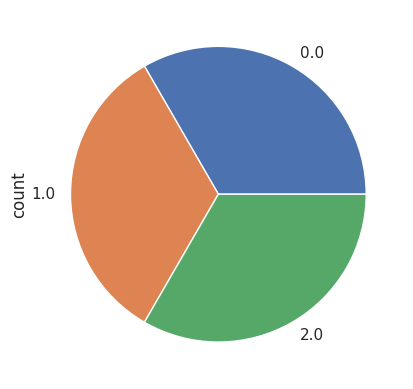

In [ ]:
df.target.value_counts().plot(kind="pie")

In [ ]:
data = df.copy()
target = data.pop("target")
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
target.head()

,target
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


###Podział danych na zbiór treningowy i testowy-iris data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, random_state=42)

print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}')
print(f'X_test shape {X_test.shape}')
print(f'y_test shape {y_test.shape}')
print(f'\nTest ratio: {len(X_test) / len(data):.2f}')
print(f'\ny_train:\n{y_train.value_counts()}')
print(f'\ny_test:\n{y_test.value_counts()}')


X_train shape (112, 4)
y_train shape (112,)
X_test shape (38, 4)
y_test shape (38,)

Test ratio: 0.25

y_train:
target
1.0    39
2.0    38
0.0    35
Name: count, dtype: int64

y_test:
target
0.0    15
2.0    12
1.0    11
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=42)

print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}')
print(f'X_test shape {X_test.shape}')
print(f'y_test shape {y_test.shape}')
print(f'\nTest ratio: {len(X_test) / len(data):.2f}')
print(f'\ny_train:\n{y_train.value_counts()}')
print(f'\ny_test:\n{y_test.value_counts()}')

X_train shape (105, 4)
y_train shape (105,)
X_test shape (45, 4)
y_test shape (45,)

Test ratio: 0.30

y_train:
target
1.0    37
2.0    37
0.0    31
Name: count, dtype: int64

y_test:
target
0.0    19
1.0    13
2.0    13
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target, train_size=0.9, random_state=42)

print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}')
print(f'X_test shape {X_test.shape}')
print(f'y_test shape {y_test.shape}')
print(f'\nTest ratio: {len(X_test) / len(data):.2f}')
print(f'\ny_train:\n{y_train.value_counts()}')
print(f'\ny_test:\n{y_test.value_counts()}')

X_train shape (135, 4)
y_train shape (135,)
X_test shape (15, 4)
y_test shape (15,)

Test ratio: 0.10

y_train:
target
2.0    47
1.0    44
0.0    44
Name: count, dtype: int64

y_test:
target
1.0    6
0.0    6
2.0    3
Name: count, dtype: int64


**Przykład wykrywania czegoś bardzo rzadkiego.** - dzielenie warstwowe.

Równy rokład zmiennej docelowej w naszym zbiorze treningowym i testowym - ma to wpływ na końcowy rezultat modelu.

Równy podział ze względu na zmienną docelową.

Jest to bardzo ważne kiedy nie mamy zbalansowanego zbioru danych jeżeli chodzi o zmienną docelową.

Dobrym przykładem jest problem wykrycia terrorysty na lotnisku.

W naszym zbiorze danych tych przykładów dotyczących rzeczywistego złapania terrorysty będzie mało.

Rozsądny podział ze względu na zmienną docelową jest bardzo ważny.

Ustawienie parametru stratify na target, jesteśmy w stanie dokonać równego podziału względem docelowej.




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.1, stratify=target)

print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}')
print(f'X_test shape {X_test.shape}')
print(f'y_test shape {y_test.shape}')
print(f'\nTest ratio: {len(X_test) / len(data):.2f}')
print(f'\ny_train:\n{y_train.value_counts()}')
print(f'\ny_test:\n{y_test.value_counts()}')

X_train shape (135, 4)
y_train shape (135,)
X_test shape (15, 4)
y_test shape (15,)

Test ratio: 0.10

y_train:
target
0.0    45
2.0    45
1.0    45
Name: count, dtype: int64

y_test:
target
1.0    5
2.0    5
0.0    5
Name: count, dtype: int64


###Podział dancyh na zbiór treningowy i testowy - breast cancer data

In [ ]:
from sklearn.datasets import load_breast_cancer

raw_data = load_breast_cancer()
raw_data_copy = raw_data.copy()
raw_data_copy.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
print(raw_data_copy['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
data = raw_data_copy['data']
target = raw_data_copy['target']

print(f'{data[:5]}\n')
print(target[:5])

[[17.99 10.38 122.80 1001.00 0.12 0.28 0.30 0.15 0.24 0.08 1.09 0.91 8.59 153.40 0.01 0.05 0.05 0.02 0.03 0.01 25.38 17.33 184.60 2019.00 0.16 0.67 0.71 0.27 0.46 0.12]
 [20.57 17.77 132.90 1326.00 0.08 0.08 0.09 0.07 0.18 0.06 0.54 0.73 3.40 74.08 0.01 0.01 0.02 0.01 0.01 0.00 24.99 23.41 158.80 1956.00 0.12 0.19 0.24 0.19 0.28 0.09]
 [19.69 21.25 130.00 1203.00 0.11 0.16 0.20 0.13 0.21 0.06 0.75 0.79 4.58 94.03 0.01 0.04 0.04 0.02 0.02 0.00 23.57 25.53 152.50 1709.00 0.14 0.42 0.45 0.24 0.36 0.09]
 [11.42 20.38 77.58 386.10 0.14 0.28 0.24 0.11 0.26 0.10 0.50 1.16 3.44 27.23 0.01 0.07 0.06 0.02 0.06 0.01 14.91 26.50 98.87 567.70 0.21 0.87 0.69 0.26 0.66 0.17]
 [20.29 14.34 135.10 1297.00 0.10 0.13 0.20 0.10 0.18 0.06 0.76 0.78 5.44 94.44 0.01 0.02 0.06 0.02 0.02 0.01 22.54 16.67 152.20 1575.00 0.14 0.20 0.40 0.16 0.24 0.08]]

[0 0 0 0 0]


In [ ]:
all_data = np.c_[data, target]
all_data[:5]

array([[17.99, 10.38, 122.80, 1001.00, 0.12, 0.28, 0.30, 0.15, 0.24, 0.08, 1.09, 0.91, 8.59, 153.40, 0.01, 0.05, 0.05, 0.02, 0.03, 0.01, 25.38, 17.33, 184.60, 2019.00, 0.16, 0.67, 0.71, 0.27, 0.46, 0.12, 0.00],
       [20.57, 17.77, 132.90, 1326.00, 0.08, 0.08, 0.09, 0.07, 0.18, 0.06, 0.54, 0.73, 3.40, 74.08, 0.01, 0.01, 0.02, 0.01, 0.01, 0.00, 24.99, 23.41, 158.80, 1956.00, 0.12, 0.19, 0.24, 0.19, 0.28, 0.09, 0.00],
       [19.69, 21.25, 130.00, 1203.00, 0.11, 0.16, 0.20, 0.13, 0.21, 0.06, 0.75, 0.79, 4.58, 94.03, 0.01, 0.04, 0.04, 0.02, 0.02, 0.00, 23.57, 25.53, 152.50, 1709.00, 0.14, 0.42, 0.45, 0.24, 0.36, 0.09, 0.00],
       [11.42, 20.38, 77.58, 386.10, 0.14, 0.28, 0.24, 0.11, 0.26, 0.10, 0.50, 1.16, 3.44, 27.23, 0.01, 0.07, 0.06, 0.02, 0.06, 0.01, 14.91, 26.50, 98.87, 567.70, 0.21, 0.87, 0.69, 0.26, 0.66, 0.17, 0.00],
       [20.29, 14.34, 135.10, 1297.00, 0.10, 0.13, 0.20, 0.10, 0.18, 0.06, 0.76, 0.78, 5.44, 94.44, 0.01, 0.02, 0.06, 0.02, 0.02, 0.01, 22.54, 16.67, 152.20, 1575.

In [ ]:
df = pd.DataFrame(data=all_data, columns=list(raw_data['feature_names']) + ['target'])
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [ ]:
df.target.value_counts()

,count
target,
1.0,357
0.0,212


Aby klasa 1 nie zdominowała modelu, lepiej będzie podzielić dane warstwowo,  z wykorzystaniem parametru stratify=target

In [ ]:
data = df.copy()
target = data.pop('target')
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
target.head()

,target
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.25, random_state=40)

print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}')
print(f'X_test shape {X_test.shape}')
print(f'y_test shape {y_test.shape}')
print(f'\nTest ratio: {len(X_test) / len(data):.2f}')
print(f'\ntarget:\n{target.value_counts() / len(target)}')
print(f'\ny_train:\n{y_train.value_counts() / len(y_train)}')
print(f'\ny_test:\n{y_test.value_counts() / len(y_test)}')

X_train shape (426, 30)
y_train shape (426,)
X_test shape (143, 30)
y_test shape (143,)

Test ratio: 0.25

target:
target
1.0    0.627417
0.0    0.372583
Name: count, dtype: float64

y_train:
target
1.0    0.607981
0.0    0.392019
Name: count, dtype: float64

y_test:
target
1.0    0.685315
0.0    0.314685
Name: count, dtype: float64


###Równy podział ze wzgledu na zmienną docelową

Teraz mamy target równo rozłożony

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.25, random_state=40, stratify=target)

print(f'X_train shape {X_train.shape}')
print(f'y_train shape {y_train.shape}')
print(f'X_test shape {X_test.shape}')
print(f'y_test shape {y_test.shape}')
print(f'\nTest ratio: {len(X_test) / len(data):.2f}')
print(f'\ntarget:\n{target.value_counts() / len(target)}')
print(f'\ny_train:\n{y_train.value_counts() / len(y_train)}')
print(f'\ny_test:\n{y_test.value_counts() / len(y_test)}')

X_train shape (426, 30)
y_train shape (426,)
X_test shape (143, 30)
y_test shape (143,)

Test ratio: 0.25

target:
target
1.0    0.627417
0.0    0.372583
Name: count, dtype: float64

y_train:
target
1.0    0.626761
0.0    0.373239
Name: count, dtype: float64

y_test:
target
1.0    0.629371
0.0    0.370629
Name: count, dtype: float64
